
# Fashion MNIST CNN From Scratch

This notebook implements a Convolutional Neural Network completely from scratch using only NumPy.

Implemented:
- Convolution Layer
- MaxPool Layer
- Flatten Layer
- Fully Connected Layer
- Forward Pass
- Backpropagation
- Training Loop
- Evaluation on Fashion MNIST


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


np.random.seed(42)

In [2]:
'''
# Load dataset

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# Add channel dimension
X_train = X_train[:, np.newaxis, :, :]
X_test = X_test[:, np.newaxis, :, :]

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)'''

'\n# Load dataset\n\n(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()\n\n# Normalize\nX_train = X_train.astype(np.float32) / 255.0\nX_test = X_test.astype(np.float32) / 255.0\n\n# Add channel dimension\nX_train = X_train[:, np.newaxis, :, :]\nX_test = X_test[:, np.newaxis, :, :]\n\nprint("Train Shape:", X_train.shape)\nprint("Test Shape:", X_test.shape)'

In [3]:

train_df = pd.read_csv("mnist_train.csv")
test_df = pd.read_csv("mnist_test.csv")

# Labels
y_train = train_df.iloc[:, 0].values
y_test = test_df.iloc[:, 0].values

# Images
X_train = train_df.iloc[:, 1:].values
X_test = test_df.iloc[:, 1:].values

# Normalize
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# Reshape into images
X_train = X_train.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)

print(X_train.shape)
print(X_test.shape)

(60000, 1, 28, 28)
(10000, 1, 28, 28)


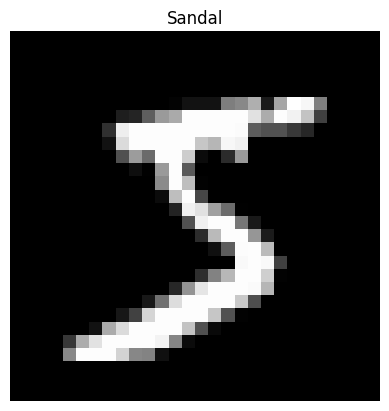

In [4]:

# Visualize sample

classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress",
    "Coat", "Sandal", "Shirt", "Sneaker",
    "Bag", "Ankle boot"
]

plt.imshow(X_train[0][0], cmap='gray')
plt.title(classes[y_train[0]])
plt.axis('off')
plt.show()


# Activation Functions


In [5]:

class ReLU:

    def forward(self, x):
        self.input = x
        return np.maximum(0, x)

    def backward(self, grad_output):
        grad = grad_output.copy()
        grad[self.input <= 0] = 0
        return grad


# Convolution Layer


In [6]:

class ConvLayer:

    def __init__(self, num_filters, filter_size, input_depth):

        self.num_filters = num_filters
        self.filter_size = filter_size

        self.filters = np.random.randn(
            num_filters,
            input_depth,
            filter_size,
            filter_size
        ) / (filter_size * filter_size)

        self.biases = np.zeros((num_filters, 1))

    def forward(self, input):

        self.input = input

        batch_size, depth, height, width = input.shape

        output_height = height - self.filter_size + 1
        output_width = width - self.filter_size + 1

        output = np.zeros((
            batch_size,
            self.num_filters,
            output_height,
            output_width
        ))

        for b in range(batch_size):
            for f in range(self.num_filters):
                for i in range(output_height):
                    for j in range(output_width):

                        region = input[
                            b,
                            :,
                            i:i+self.filter_size,
                            j:j+self.filter_size
                        ]

                        output[b, f, i, j] = np.sum(
                            region * self.filters[f]
                        ) + self.biases[f,0]

        return output

    def backward(self, grad_output, learning_rate):

        batch_size, depth, height, width = self.input.shape

        grad_filters = np.zeros_like(self.filters)
        grad_biases = np.zeros_like(self.biases)
        grad_input = np.zeros_like(self.input)

        output_height = height - self.filter_size + 1
        output_width = width - self.filter_size + 1

        for b in range(batch_size):
            for f in range(self.num_filters):
                for i in range(output_height):
                    for j in range(output_width):

                        region = self.input[
                            b,
                            :,
                            i:i+self.filter_size,
                            j:j+self.filter_size
                        ]

                        grad_filters[f] += region * grad_output[b, f, i, j]

                        grad_input[
                            b,
                            :,
                            i:i+self.filter_size,
                            j:j+self.filter_size
                        ] += self.filters[f] * grad_output[b, f, i, j]

                        grad_biases[f] += grad_output[b, f, i, j]

        self.filters -= learning_rate * grad_filters
        self.biases -= learning_rate * grad_biases

        return grad_input


# MaxPool Layer


In [7]:

class MaxPool:

    def __init__(self, size=2, stride=2):
        self.size = size
        self.stride = stride

    def forward(self, input):

        self.input = input

        batch_size, depth, height, width = input.shape

        output_height = height // self.size
        output_width = width // self.size

        output = np.zeros((
            batch_size,
            depth,
            output_height,
            output_width
        ))

        for b in range(batch_size):
            for d in range(depth):
                for i in range(output_height):
                    for j in range(output_width):

                        region = input[
                            b,
                            d,
                            i*self.stride:i*self.stride+self.size,
                            j*self.stride:j*self.stride+self.size
                        ]

                        output[b, d, i, j] = np.max(region)

        return output

    def backward(self, grad_output):

        batch_size, depth, height, width = self.input.shape

        grad_input = np.zeros_like(self.input)

        output_height = height // self.size
        output_width = width // self.size

        for b in range(batch_size):
            for d in range(depth):
                for i in range(output_height):
                    for j in range(output_width):

                        region = self.input[
                            b,
                            d,
                            i*self.stride:i*self.stride+self.size,
                            j*self.stride:j*self.stride+self.size
                        ]

                        max_value = np.max(region)

                        for m in range(self.size):
                            for n in range(self.size):
                                if region[m, n] == max_value:
                                    grad_input[
                                        b,
                                        d,
                                        i*self.stride+m,
                                        j*self.stride+n
                                    ] = grad_output[b, d, i, j]

        return grad_input


# Flatten Layer


In [8]:

class Flatten:

    def forward(self, input):
        self.input_shape = input.shape
        return input.reshape(input.shape[0], -1)

    def backward(self, grad_output):
        return grad_output.reshape(self.input_shape)


# Fully Connected Layer


In [9]:

class Dense:

    def __init__(self, input_size, output_size):

        self.weights = np.random.randn(input_size, output_size) * 0.01
        self.biases = np.zeros((1, output_size))

    def forward(self, input):

        self.input = input
        return np.dot(input, self.weights) + self.biases

    def backward(self, grad_output, learning_rate):

        grad_weights = np.dot(self.input.T, grad_output)
        grad_biases = np.sum(grad_output, axis=0, keepdims=True)

        grad_input = np.dot(grad_output, self.weights.T)

        self.weights -= learning_rate * grad_weights
        self.biases -= learning_rate * grad_biases

        return grad_input


# Softmax + Cross Entropy


In [10]:

class SoftmaxCrossEntropy:

    def forward(self, logits, labels):

        exps = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        self.probs = exps / np.sum(exps, axis=1, keepdims=True)

        self.labels = labels

        batch_size = logits.shape[0]

        loss = -np.log(self.probs[range(batch_size), labels] + 1e-9)

        return np.mean(loss)

    def backward(self):

        batch_size = self.probs.shape[0]

        grad = self.probs.copy()
        grad[range(batch_size), self.labels] -= 1

        return grad / batch_size


# Build CNN Model


In [11]:

conv = ConvLayer(num_filters=8, filter_size=3, input_depth=1)
relu1 = ReLU()
pool = MaxPool()

flatten = Flatten()

dense1 = Dense(8 * 13 * 13, 128)
relu2 = ReLU()

dense2 = Dense(128, 10)

loss_function = SoftmaxCrossEntropy()


# Training Loop


In [17]:

learning_rate = 0.001
epochs = 3
batch_size = 5

train_size = 1000  # Reduced for faster execution

X_small = X_train[:train_size]
y_small = y_train[:train_size]

losses = []

for epoch in range(epochs):

    epoch_loss = 0

    for i in range(0, train_size, batch_size):

        X_batch = X_small[i:i+batch_size]
        y_batch = y_small[i:i+batch_size]

        # Forward pass

        out = conv.forward(X_batch)
        out = relu1.forward(out)
        out = pool.forward(out)

        out = flatten.forward(out)

        out = dense1.forward(out)
        out = relu2.forward(out)

        logits = dense2.forward(out)

        loss = loss_function.forward(logits, y_batch)

        epoch_loss += loss

        # Backward pass

        grad = loss_function.backward()

        grad = dense2.backward(grad, learning_rate)
        grad = relu2.backward(grad)

        grad = dense1.backward(grad, learning_rate)

        grad = flatten.backward(grad)

        grad = pool.backward(grad)
        grad = relu1.backward(grad)

        grad = conv.backward(grad, learning_rate)

    avg_loss = epoch_loss / (train_size // batch_size)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 2.3016
Epoch 2, Loss: 2.3011
Epoch 3, Loss: 2.3005



# Plot Loss


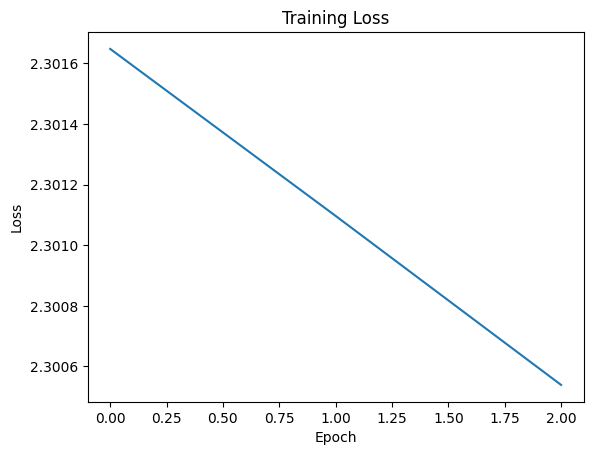

In [18]:

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()



# Evaluation


In [19]:

def predict(X):

    out = conv.forward(X)
    out = relu1.forward(out)
    out = pool.forward(out)

    out = flatten.forward(out)

    out = dense1.forward(out)
    out = relu2.forward(out)

    logits = dense2.forward(out)

    return np.argmax(logits, axis=1)

test_subset = 500

predictions = predict(X_test[:test_subset])

accuracy = np.mean(predictions == y_test[:test_subset])

print("Test Accuracy:", accuracy)


Test Accuracy: 0.118
